# Hybrid Stacking XAU/USD — Visualization Pipeline

## 1. Setup

In [1]:
import warnings
import time
warnings.filterwarnings("ignore")

import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import matplotlib.gridspec as gridspec
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score,
)

from accelerate import Accelerator
from accelerate.utils import set_seed
from src.backtest import backtest_signals, simulate_equity
from src.config import (
    CV_SPLITS,
    DATA_DIR,
    EMBARGO_PCT,
    FRACTIONAL_D,
    INITIAL_BALANCE,
    LABELS,
    MIN_OOF_F1,
    PURGE_PCT,
    RANDOM_STATE,
    REPORT_DIR,
    WAVELET,
    WAVELET_LEVEL,
    PipelineConfig,
)
from src.data import parquet_files
from src.dataset import (
    build_dataset,
    feature_columns,
    train_test_time_split,
)
from src.features import fractional_diff, rolling_wavelet_denoise
from src.models import HybridStackingSignalClassifier
from src.validation import PurgedEmbargoTimeSeriesSplit

pd.set_option("display.max_columns", 80)
pd.set_option("display.width", 140)

plt.style.use("seaborn-v0_8-whitegrid")
plt.rcParams.update({
    "figure.dpi": 120,
    "savefig.dpi": 160,
    "font.size": 10,
    "axes.titlesize": 12,
    "axes.labelsize": 10,
})

PALETTE = {1: "#2ca02c", 0: "#7f7f7f", -1: "#d62728"}
LABEL_NAMES = {-1: "SHORT", 0: "HOLD", 1: "LONG"}
LABEL_ORDER = list(LABELS)

set_seed(RANDOM_STATE)
accelerator = Accelerator()
print(f"Accelerate device: {accelerator.device} | processes: {accelerator.num_processes}")

_t0 = time.perf_counter()
_timings = {}
_figures = []
if not hasattr(plt, "_hybrid_original_figure"):
    plt._hybrid_original_figure = plt.figure
    plt._hybrid_original_subplots = plt.subplots
_plt_figure = plt._hybrid_original_figure
_plt_subplots = plt._hybrid_original_subplots

def _remember_figure(fig):
    if fig not in _figures:
        _figures.append(fig)
    return fig

def figure(*args, **kwargs):
    return _remember_figure(_plt_figure(*args, **kwargs))

def subplots(*args, **kwargs):
    fig, axes = _plt_subplots(*args, **kwargs)
    return _remember_figure(fig), axes

plt.figure = figure
plt.subplots = subplots

Accelerate device: cpu | processes: 1


In [2]:
MONTHS = None
config = PipelineConfig(months=MONTHS)

files = parquet_files(DATA_DIR, config.months)
months_label = "full" if MONTHS is None else f"{MONTHS} months"
file_range = f"{files[0].stem} → {files[-1].stem}"
print(f"Data dir: {DATA_DIR.resolve()}")
print(f"Mode: {months_label} | Parquet files: {len(files)}")
print(f"File range: {file_range}")

_timings["config"] = time.perf_counter() - _t0
_t_section = time.perf_counter()

Data dir: /home/ultimatebrok/Downloads/thesis-compact/data/raw/XAUUSD
Mode: full | Parquet files: 60
File range: 2019-01 → 2023-12


## 2. Build Dataset

In [3]:
_t_section = time.perf_counter()
dataset = build_dataset(config)
train, test = train_test_time_split(dataset, purge_pct=PURGE_PCT)
features = feature_columns(dataset)

dataset_pdf = dataset.to_pandas().set_index("timestamp")
train_pdf = train.to_pandas().set_index("timestamp")
test_pdf = test.to_pandas().set_index("timestamp")

print(f"Rows: {len(dataset):,}")
print(f"Train: {len(train):,} | Test: {len(test):,}")
print(f"Features: {len(features)}")
print(f"Raw close in features: {'close' in features}")
print(f"Fractional d: {FRACTIONAL_D}")
_timings["data_loading"] = time.perf_counter() - _t_section

Split at row 23604 | timestamp: 2022-12-29 23:00:00+00:00 | purge gap: 591 rows
Train: 2019-01-03 09:00:00+00:00 → 2022-12-29 21:00:00+00:00
Test:  2023-02-06 19:00:00+00:00 → 2023-12-29 09:00:00+00:00
Rows: 29,505
Train: 23,604 | Test: 5,310
Features: 20
Raw close in features: False
Fractional d: 0.4


## 3. Price & Raw Data Visualization

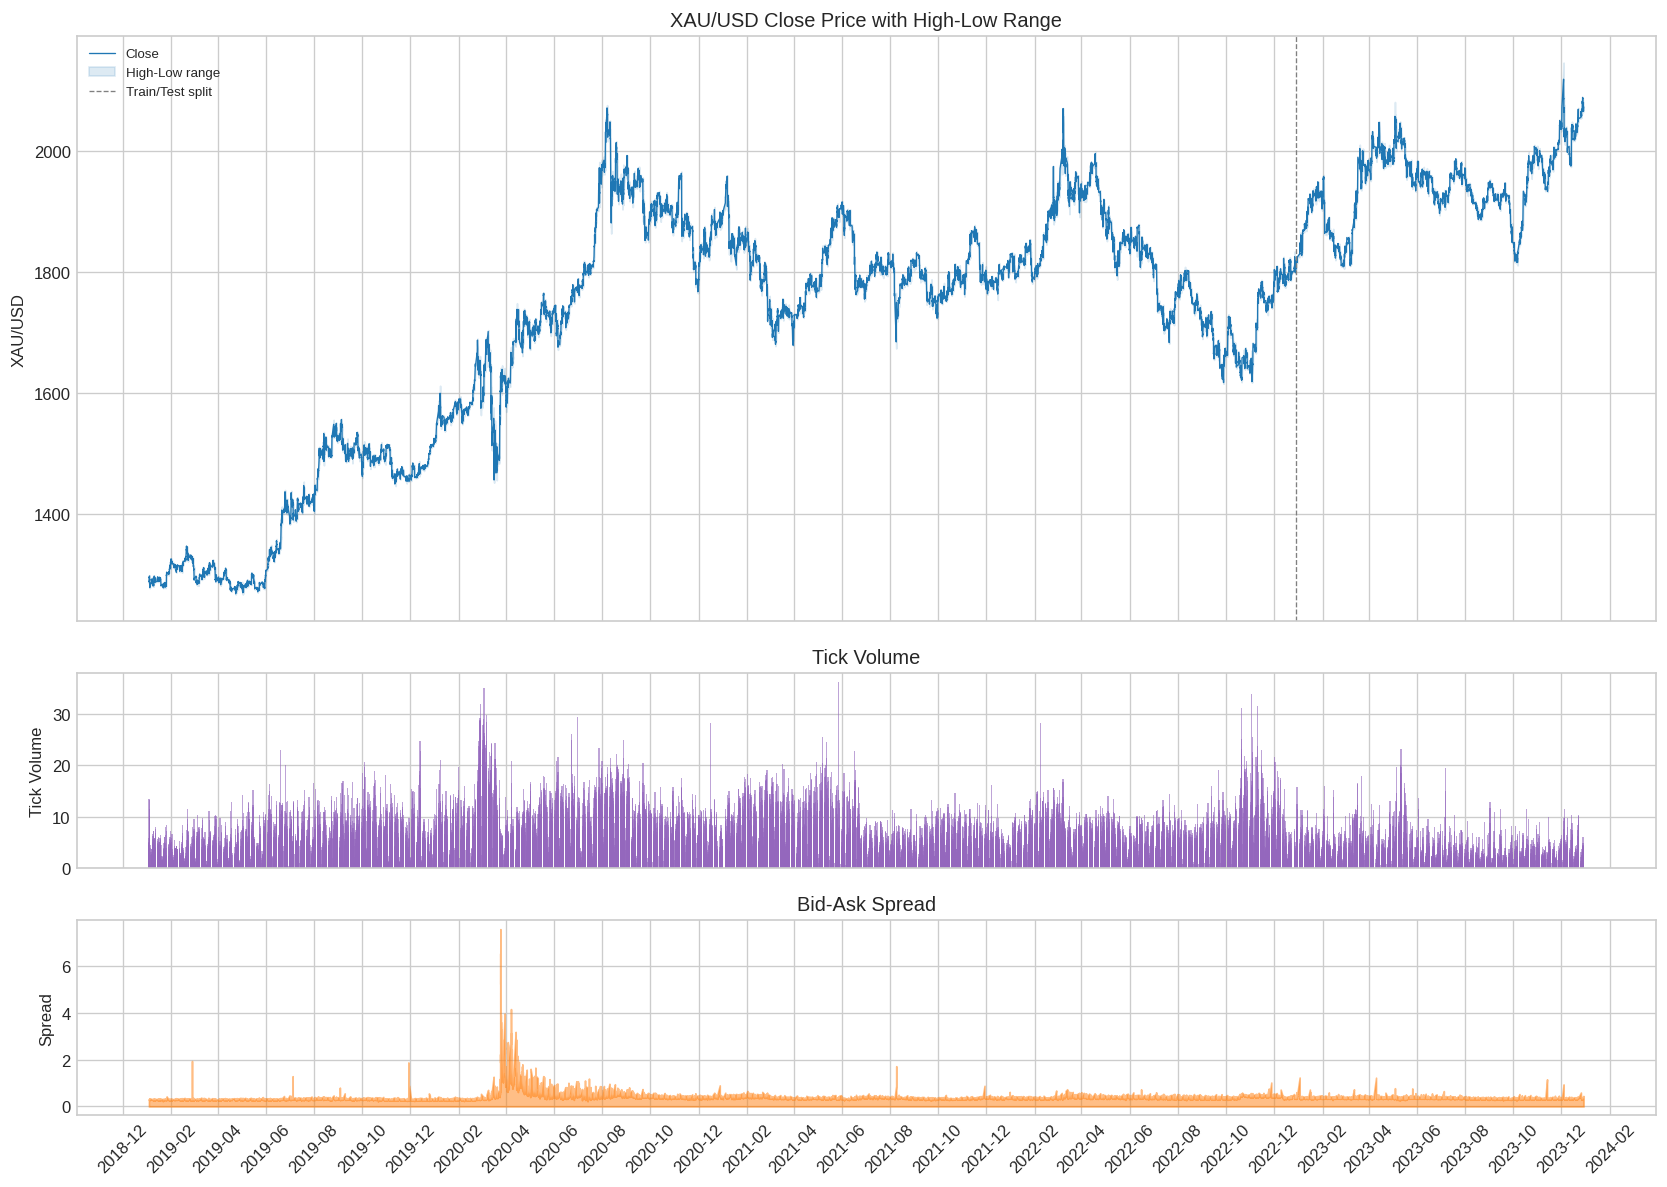

In [4]:
fig, axes = plt.subplots(3, 1, figsize=(14, 10), sharex=True, height_ratios=[3, 1, 1])

ax_price, ax_vol, ax_spread = axes

ax_price.plot(dataset_pdf.index, dataset_pdf["close"], color="#1f77b4", linewidth=0.8, label="Close")
ax_price.fill_between(dataset_pdf.index, dataset_pdf["low"], dataset_pdf["high"],
    alpha=0.15, color="#1f77b4", label="High-Low range")
ax_price.axvline(train_pdf.index[-1], color="gray", linestyle="--", linewidth=0.8, label="Train/Test split")
ax_price.set_ylabel("XAU/USD")
ax_price.legend(loc="upper left", fontsize=8)
ax_price.set_title("XAU/USD Close Price with High-Low Range")

ax_vol.bar(dataset_pdf.index, dataset_pdf["volume"], width=1.5, color="#9467bd", alpha=0.6)
ax_vol.set_ylabel("Tick Volume")
ax_vol.set_title("Tick Volume")

ax_spread.fill_between(dataset_pdf.index, 0, dataset_pdf["spread"], color="#ff7f0e", alpha=0.5)
ax_spread.set_ylabel("Spread")
ax_spread.set_title("Bid-Ask Spread")
ax_spread.xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m"))
ax_spread.xaxis.set_major_locator(mdates.MonthLocator(interval=2))
plt.xticks(rotation=45)

fig.tight_layout()
plt.show()

## 4. Label Distribution Visualization

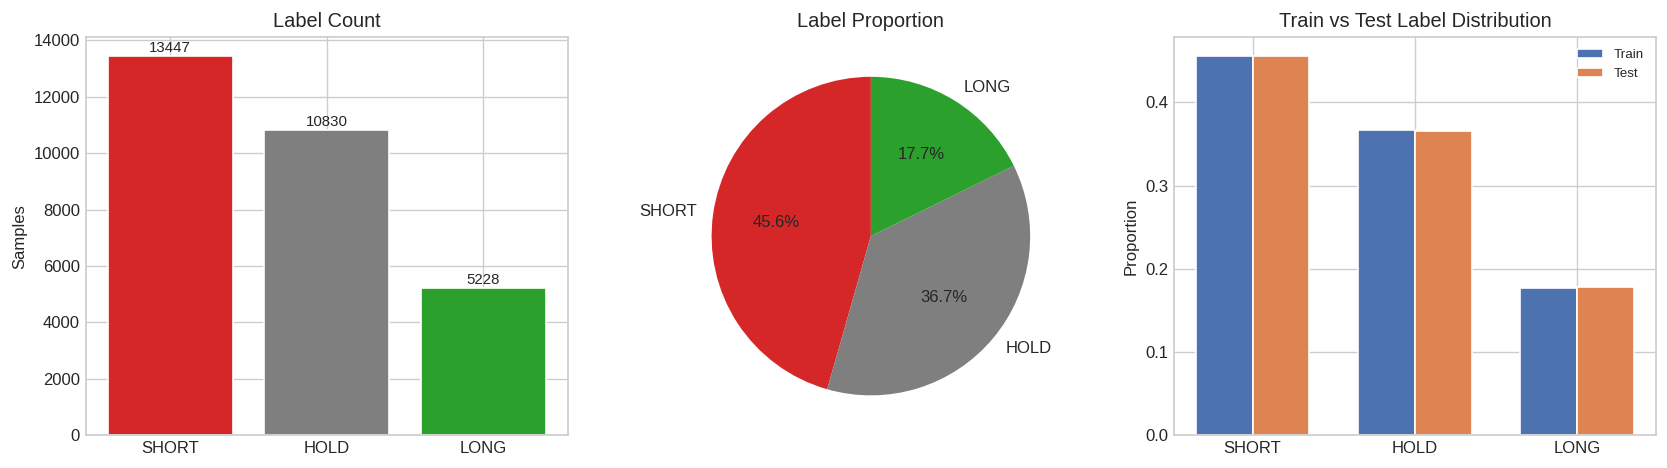

In [5]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

label_counts = dataset_pdf["label"].value_counts().reindex(LABEL_ORDER, fill_value=0)
colors = [PALETTE[k] for k in label_counts.index]

axes[0].bar(
    [LABEL_NAMES[k] for k in label_counts.index],
    label_counts.values, color=colors, edgecolor="white"
)
axes[0].set_title("Label Count")
axes[0].set_ylabel("Samples")

for i, (k, v) in enumerate(label_counts.items()):
    axes[0].text(i, v + max(label_counts) * 0.01, str(v), ha="center", fontsize=9)

label_pct = dataset_pdf["label"].value_counts(normalize=True).reindex(LABEL_ORDER, fill_value=0) * 100
axes[1].pie(
    label_pct.values, labels=[LABEL_NAMES[k] for k in label_pct.index],
    colors=colors, autopct="%.1f%%", startangle=90
)
axes[1].set_title("Label Proportion")

train_labels = train_pdf["label"].value_counts(normalize=True).reindex(LABEL_ORDER, fill_value=0)
test_labels = test_pdf["label"].value_counts(normalize=True).reindex(LABEL_ORDER, fill_value=0)
x = np.arange(len(LABEL_ORDER))
width = 0.35
axes[2].bar(x - width/2, train_labels.values, width, label="Train", color="#4c72b0", edgecolor="white")
axes[2].bar(x + width/2, test_labels.values, width, label="Test", color="#dd8452", edgecolor="white")
axes[2].set_xticks(x)
axes[2].set_xticklabels([LABEL_NAMES[k] for k in LABEL_ORDER])
axes[2].set_title("Train vs Test Label Distribution")
axes[2].set_ylabel("Proportion")
axes[2].legend(fontsize=8)

fig.tight_layout()
plt.show()

## 5. Price with Triple Barrier Labels

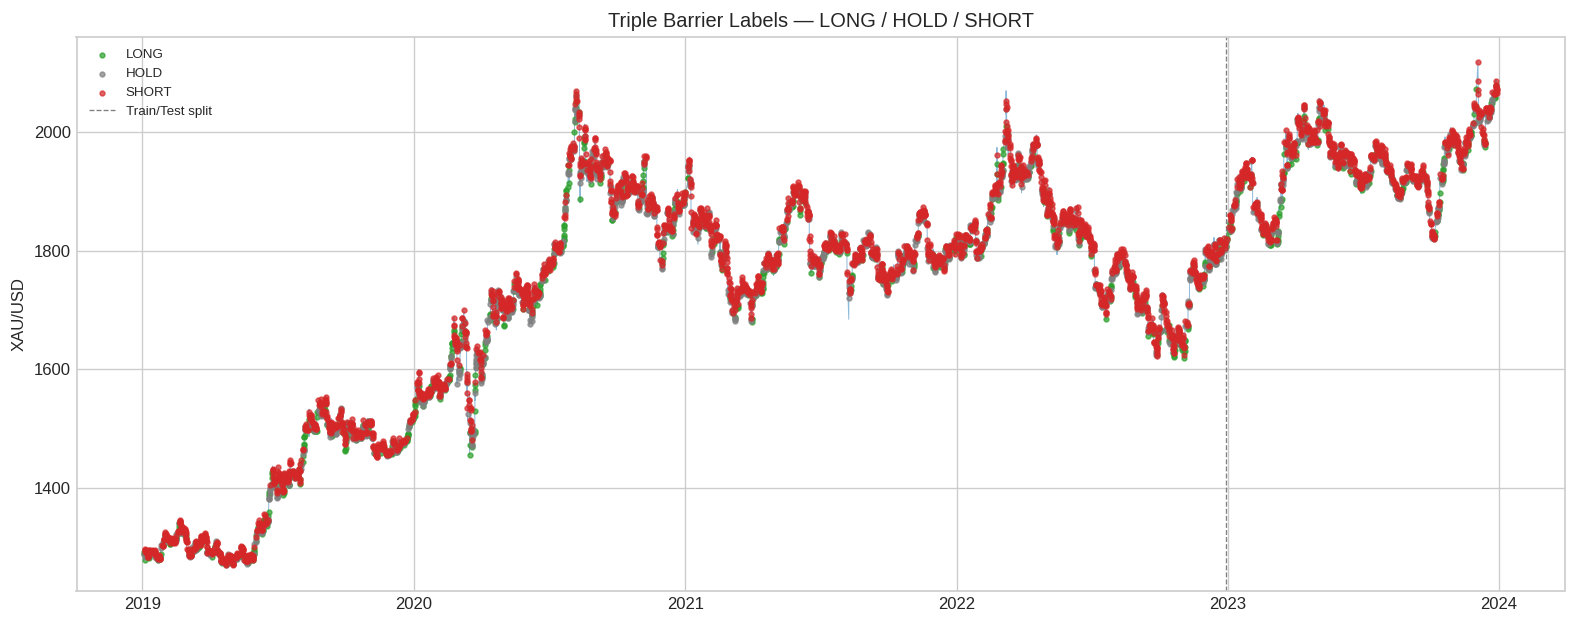

In [6]:
fig, ax = plt.subplots(figsize=(16, 6))

sample = dataset_pdf.iloc[::4]
ax.plot(dataset_pdf.index, dataset_pdf["close"], color="#1f77b4", linewidth=0.6, alpha=0.5)

for label_val, color in PALETTE.items():
    mask = sample["label"] == label_val
    ax.scatter(
        sample.index[mask], sample.loc[mask, "close"],
        c=color, s=8, alpha=0.7, label=LABEL_NAMES[label_val], zorder=3
    )

ax.axvline(train_pdf.index[-1], color="gray", linestyle="--", linewidth=0.8, label="Train/Test split")
ax.set_title("Triple Barrier Labels — LONG / HOLD / SHORT")
ax.set_ylabel("XAU/USD")
ax.legend(fontsize=8)

## 6. Feature Engineering Visualization

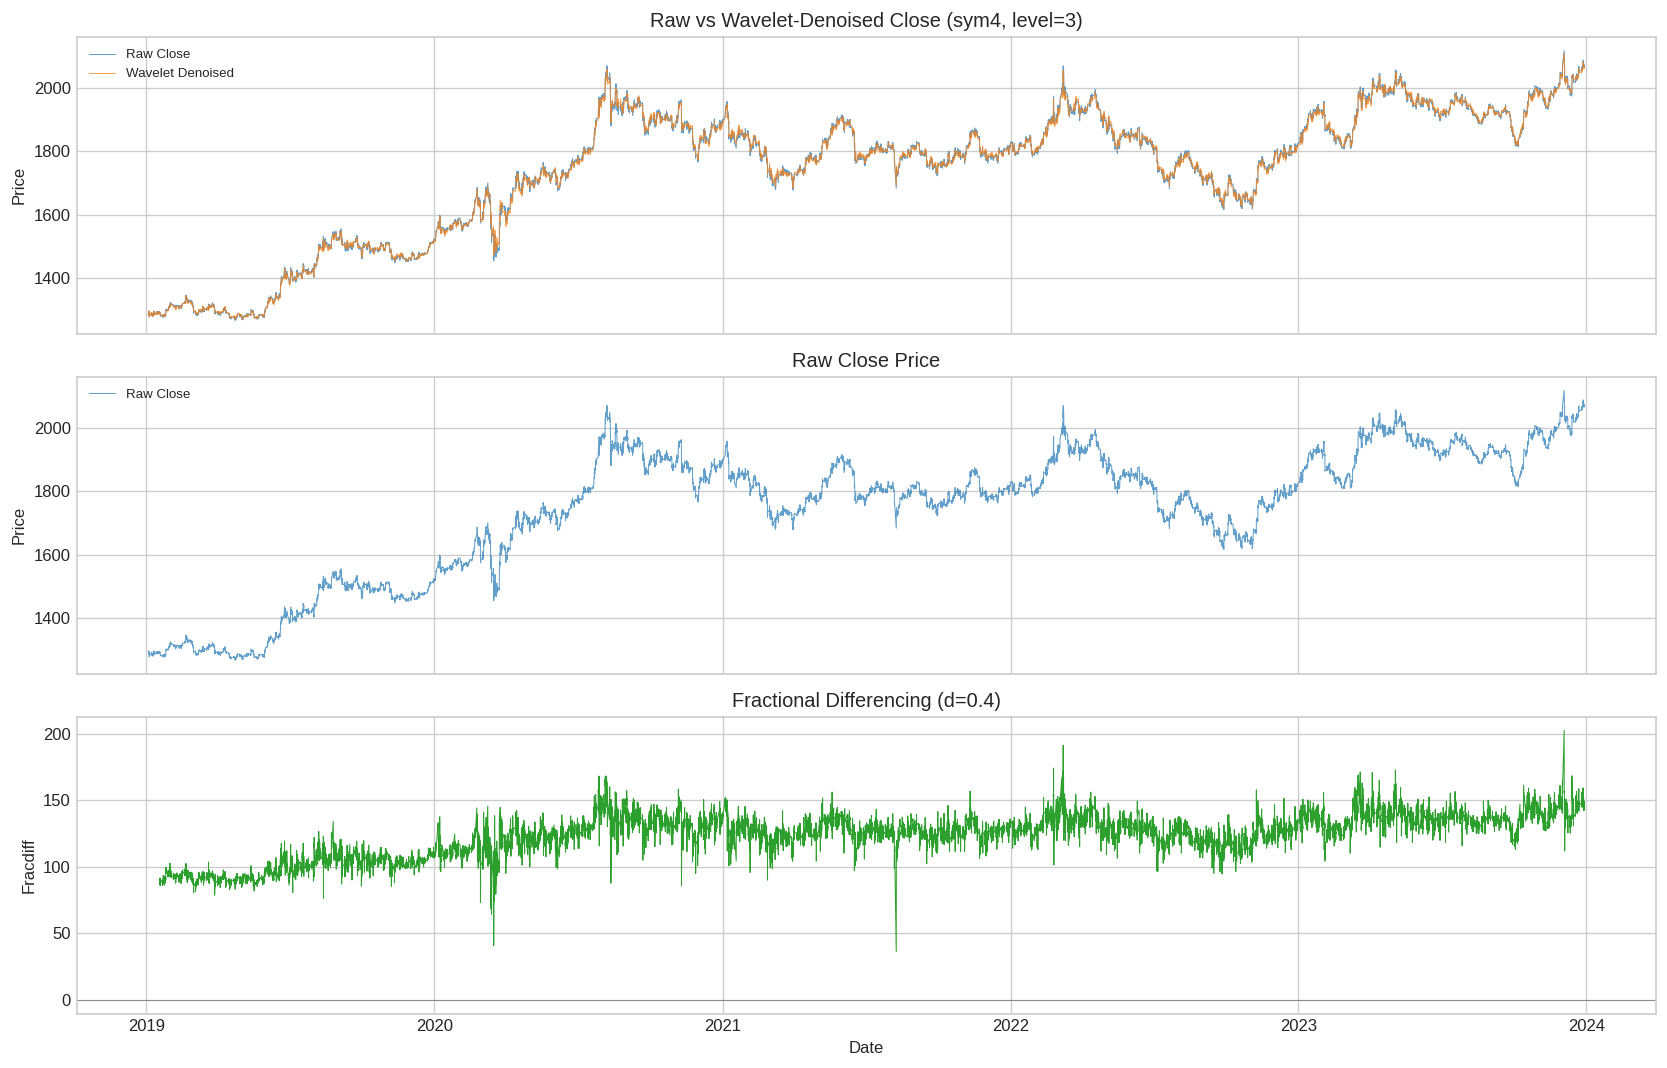

In [7]:
fig, axes = plt.subplots(3, 1, figsize=(14, 9), sharex=True)

axes[0].plot(dataset_pdf.index, dataset_pdf["close"], color="#1f77b4", linewidth=0.6, alpha=0.7, label="Raw Close")
axes[0].plot(dataset_pdf.index, dataset_pdf["close_denoised"], color="#ff7f0e", linewidth=0.6, alpha=0.7, label="Wavelet Denoised")
axes[0].set_title(f"Raw vs Wavelet-Denoised Close ({WAVELET}, level={WAVELET_LEVEL})")
axes[0].legend(fontsize=8)
axes[0].set_ylabel("Price")

axes[1].plot(dataset_pdf.index, dataset_pdf["close"], color="#1f77b4", linewidth=0.6, alpha=0.7, label="Raw Close")
axes[1].set_title("Raw Close Price")
axes[1].legend(fontsize=8)
axes[1].set_ylabel("Price")

axes[2].plot(dataset_pdf.index, dataset_pdf["close_fracdiff"], color="#2ca02c", linewidth=0.6)
axes[2].set_title(f"Fractional Differencing (d={FRACTIONAL_D})")
axes[2].set_ylabel("Fracdiff")
axes[2].set_xlabel("Date")
axes[2].axhline(0, color="gray", linewidth=0.5)

fig.tight_layout()

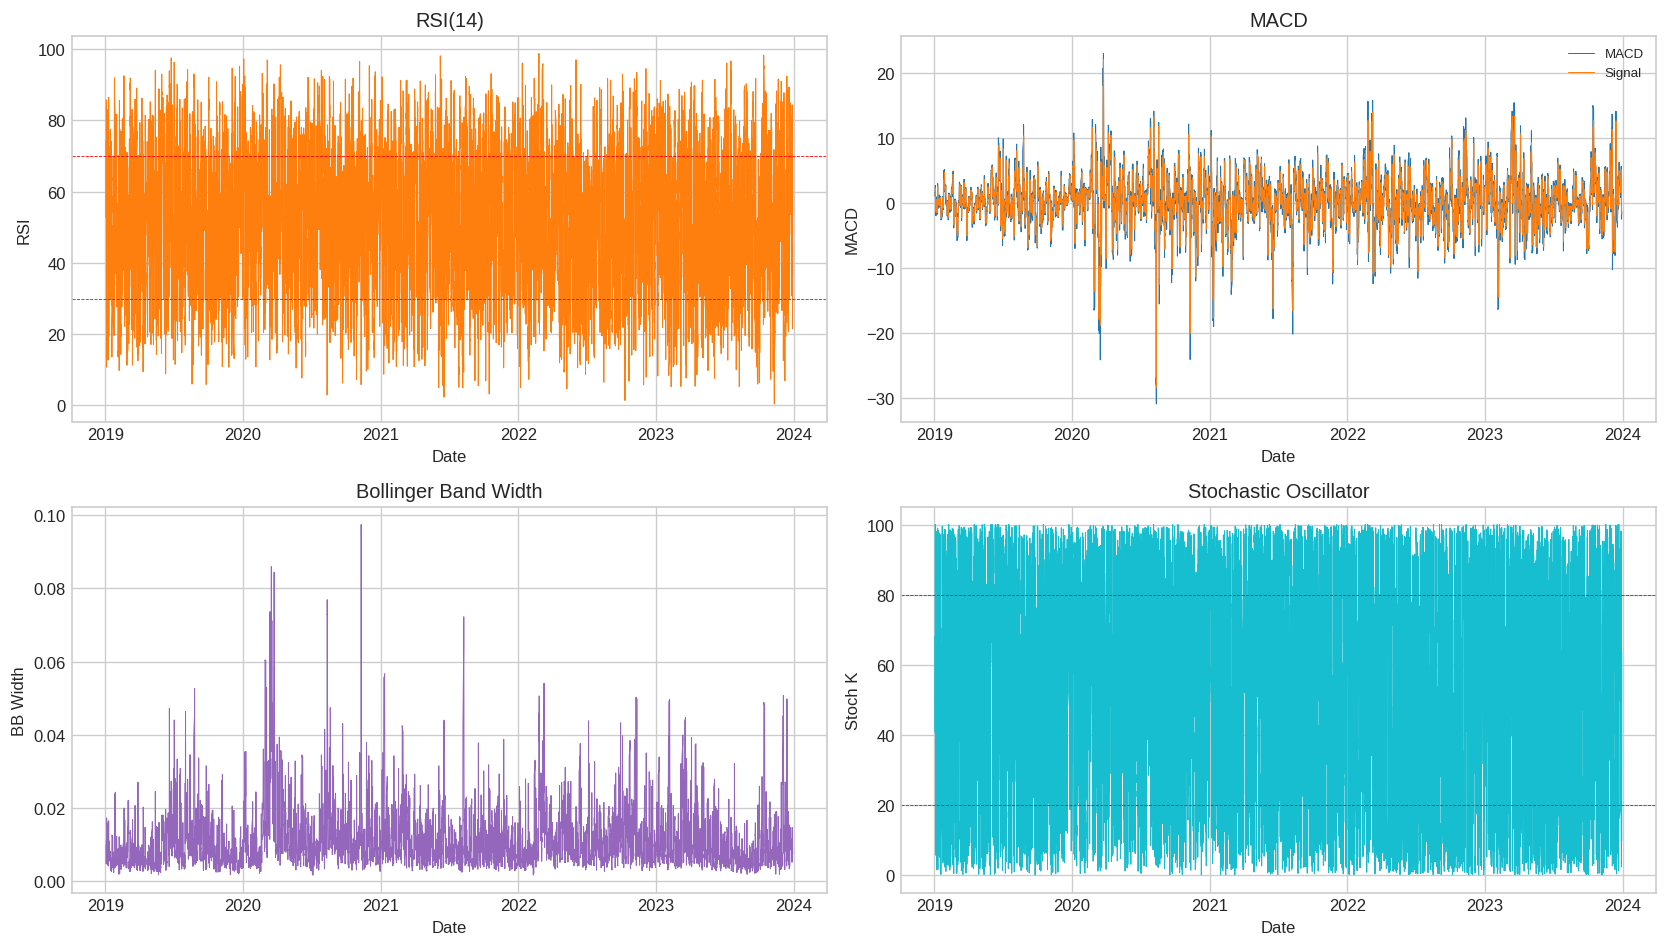

In [8]:
fig, axes = plt.subplots(2, 2, figsize=(14, 8))

axes[0, 0].plot(dataset_pdf.index, dataset_pdf["rsi_14"], color="#ff7f0e", linewidth=0.6)
axes[0, 0].axhline(70, color="red", linewidth=0.5, linestyle="--")
axes[0, 0].axhline(30, color="green", linewidth=0.5, linestyle="--")
axes[0, 0].fill_between(dataset_pdf.index, 30, 70, alpha=0.1, color="gray")
axes[0, 0].set_title("RSI(14)")
axes[0, 0].set_ylabel("RSI")

axes[0, 1].plot(dataset_pdf.index, dataset_pdf["macd"], color="#1f77b4", linewidth=0.6, label="MACD")
axes[0, 1].plot(dataset_pdf.index, dataset_pdf["macd_signal"], color="#ff7f0e", linewidth=0.6, label="Signal")
axes[0, 1].legend(fontsize=8)
axes[0, 1].set_title("MACD")
axes[0, 1].set_ylabel("MACD")

axes[1, 0].plot(dataset_pdf.index, dataset_pdf["bb_width"], color="#9467bd", linewidth=0.6)
axes[1, 0].set_title("Bollinger Band Width")
axes[1, 0].set_ylabel("BB Width")

axes[1, 1].plot(dataset_pdf.index, dataset_pdf["stoch_14"], color="#17becf", linewidth=0.6)
axes[1, 1].axhline(80, color="red", linewidth=0.5, linestyle="--")
axes[1, 1].axhline(20, color="green", linewidth=0.5, linestyle="--")
axes[1, 1].set_title("Stochastic Oscillator")
axes[1, 1].set_ylabel("Stoch K")

for ax in axes.flat:
    ax.set_xlabel("Date")

fig.tight_layout()

Text(0.5, 1.0, 'Feature Correlation Matrix')

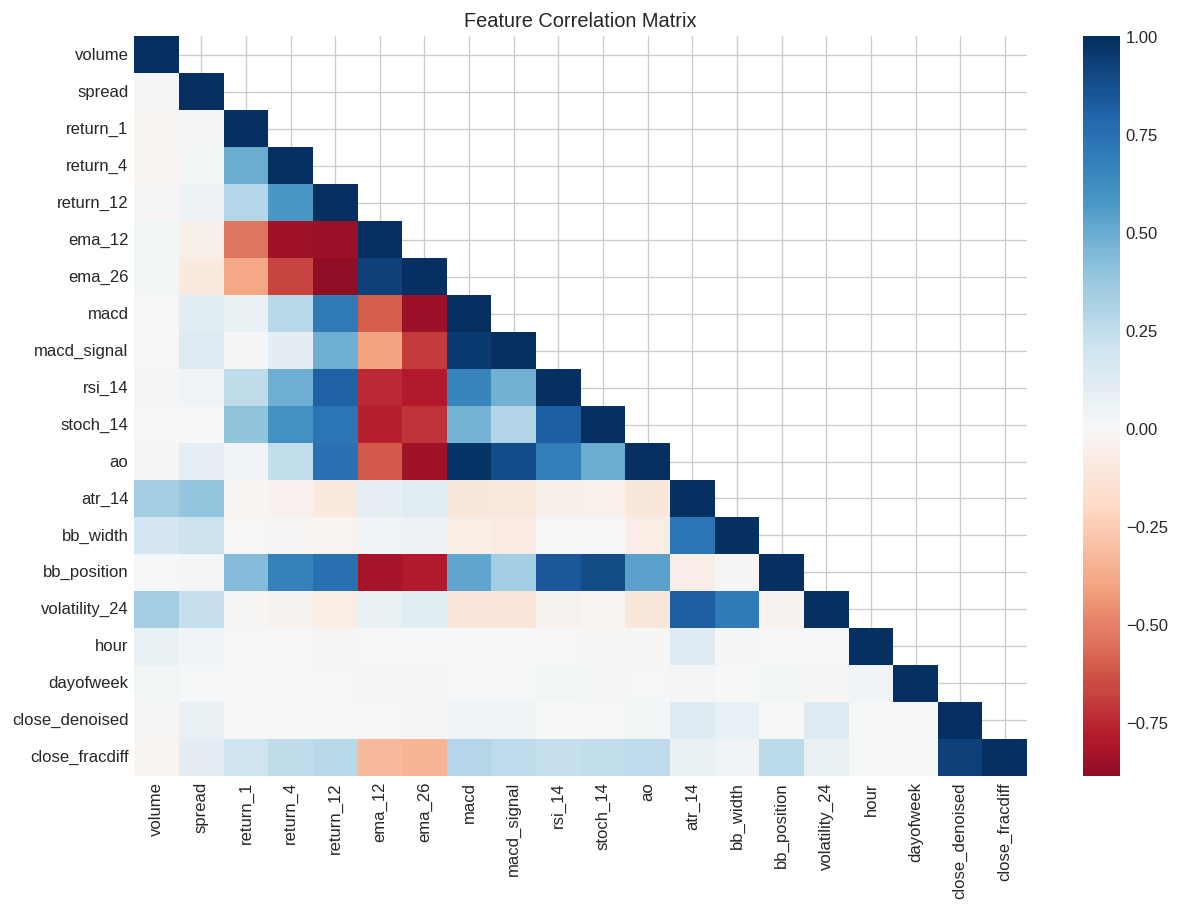

In [9]:
fig, ax = plt.subplots(figsize=(12, 8))

corr_cols = [c for c in features if c in dataset_pdf.columns]
corr = dataset_pdf[corr_cols].corr()
mask = np.triu(np.ones_like(corr, dtype=bool), k=1)

sns.heatmap(corr, mask=mask, annot=False, cmap="RdBu", center=0,
            xticklabels=corr.columns, yticklabels=corr.columns, ax=ax)
ax.set_title("Feature Correlation Matrix")

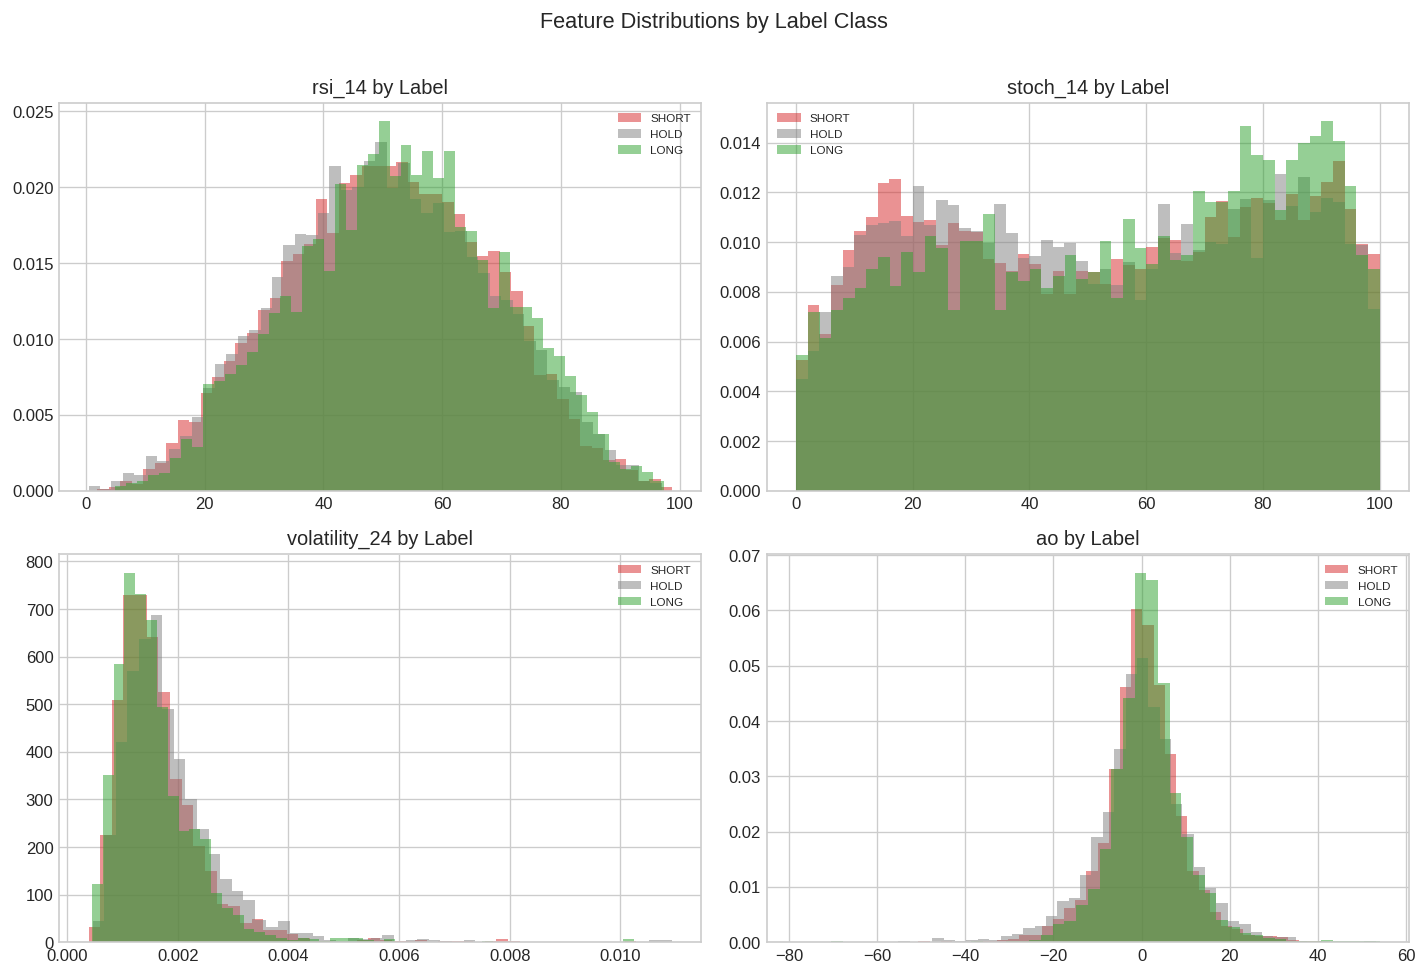

In [10]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8))

for ax, col in zip(axes.flat, ["rsi_14", "stoch_14", "volatility_24", "ao"]):
    for label_val in [-1, 0, 1]:
        subset = dataset_pdf.loc[dataset_pdf["label"] == label_val, col].dropna()
        ax.hist(subset, bins=50, alpha=0.5, color=PALETTE[label_val], label=LABEL_NAMES[label_val], density=True)
    ax.set_title(f"{col} by Label")
    ax.legend(fontsize=7)

fig.suptitle("Feature Distributions by Label Class", fontsize=13, y=1.01)
fig.tight_layout()
plt.show()

## 7. Purged Embargo CV Splits

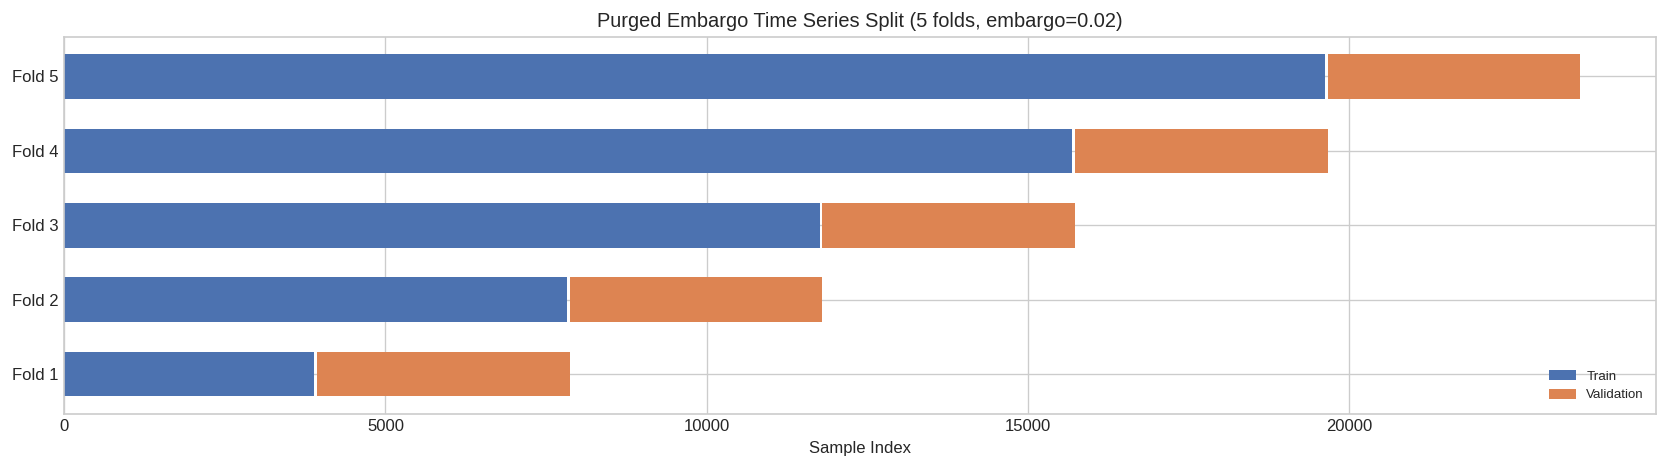

In [11]:
cv = PurgedEmbargoTimeSeriesSplit(CV_SPLITS, EMBARGO_PCT)

fig, ax = plt.subplots(figsize=(14, 4))

for fold, (train_idx, val_idx) in enumerate(cv.split(train[features], train["event_end"])):
    ax.barh(fold, len(train_idx), left=train_idx[0], color="#4c72b0", height=0.6, label="Train" if fold == 0 else "")
    ax.barh(fold, len(val_idx), left=val_idx[0], color="#dd8452", height=0.6, label="Validation" if fold == 0 else "")

ax.set_yticks(range(CV_SPLITS))
ax.set_yticklabels([f"Fold {i+1}" for i in range(CV_SPLITS)])
ax.set_xlabel("Sample Index")
ax.set_title(f"Purged Embargo Time Series Split ({CV_SPLITS} folds, embargo={EMBARGO_PCT})")
ax.legend(loc="lower right", fontsize=8)
fig.tight_layout()
plt.show()

## 8. Train Model

In [12]:
_t_section = time.perf_counter()
model = HybridStackingSignalClassifier(
    n_splits=CV_SPLITS,
    embargo_pct=EMBARGO_PCT,
    min_oof_f1=MIN_OOF_F1,
    random_state=RANDOM_STATE,
)
model.fit(train[features], train["label"], train["event_end"])
print("Training complete.")
_timings["model_training"] = time.perf_counter() - _t_section

Training complete.


## 9. OOF Scores Visualization

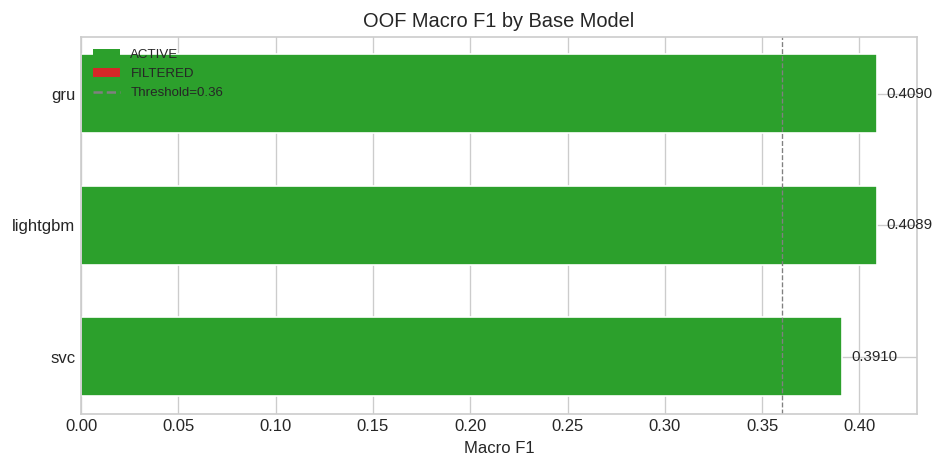

In [13]:
from matplotlib.patches import Patch

scores = pd.Series(model.oof_scores_).sort_values()
colors = ["#2ca02c" if n in model.active_model_names_ else "#d62728" for n in scores.index]

fig, ax = plt.subplots(figsize=(8, 4))
bars = ax.barh(scores.index, scores.values, color=colors, edgecolor="white", height=0.6)
ax.axvline(MIN_OOF_F1, color="gray", linestyle="--", linewidth=0.8, label=f"Min OOF F1 = {MIN_OOF_F1}")

for bar, val in zip(bars, scores.values):
    ax.text(val + 0.005, bar.get_y() + bar.get_height()/2, f"{val:.4f}", va="center", fontsize=9)

legend_elements = [
    Patch(facecolor="#2ca02c", label="ACTIVE"),
    Patch(facecolor="#d62728", label="FILTERED"),
    plt.Line2D([0], [0], color="gray", linestyle="--", label=f"Threshold={MIN_OOF_F1}"),
]
ax.legend(handles=legend_elements, fontsize=8)
ax.set_title("OOF Macro F1 by Base Model")
ax.set_xlabel("Macro F1")
fig.tight_layout()
plt.show()

## 10. Test Set Evaluation

In [14]:
predictions = model.predict(test[features])
positions = model.predict_positions(test[features])
pred_proba = model.predict_proba(test[features])

y_true = test["label"].to_numpy()
print(f"Accuracy: {accuracy_score(y_true, predictions):.4f}")
print(f"F1 macro: {f1_score(y_true, predictions, average='macro', zero_division=0):.4f}")
print(classification_report(y_true, predictions, zero_division=0))

Accuracy: 0.3770
F1 macro: 0.3722
              precision    recall  f1-score   support

        -1.0       0.36      0.10      0.16      2421
         0.0       0.68      0.50      0.58      1940
         1.0       0.25      0.83      0.38       949

    accuracy                           0.38      5310
   macro avg       0.43      0.48      0.37      5310
weighted avg       0.46      0.38      0.35      5310



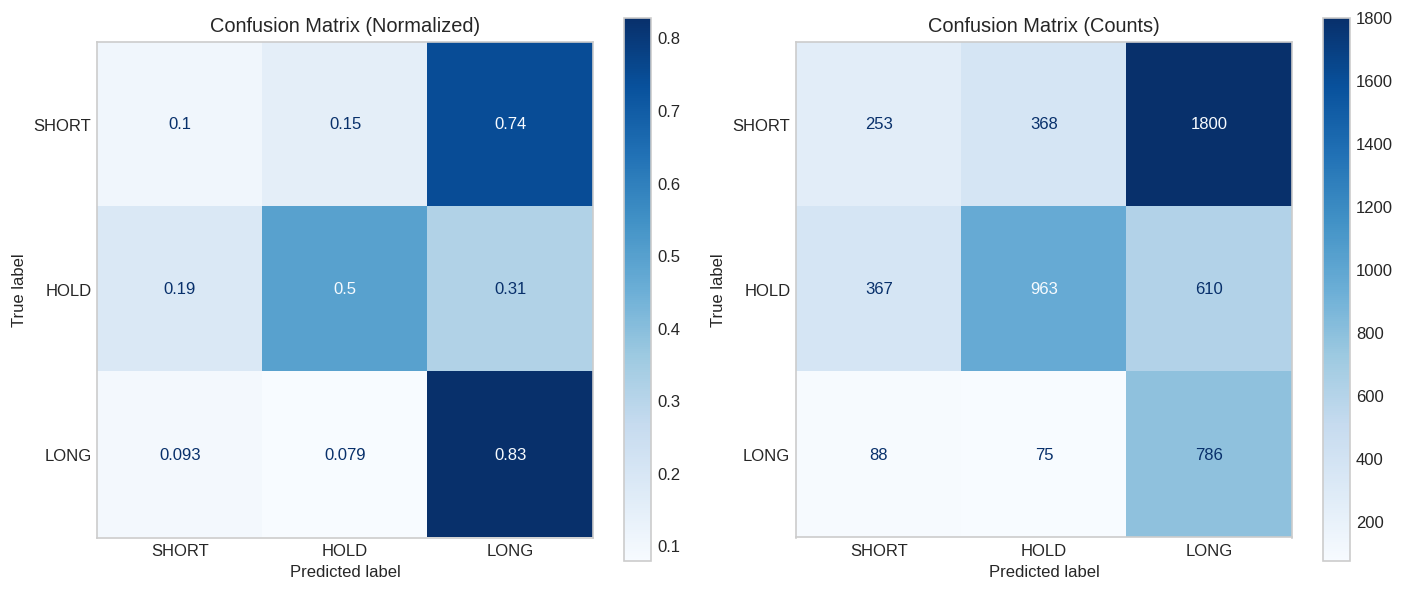

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

ConfusionMatrixDisplay.from_predictions(
    y_true, predictions,
    labels=LABEL_ORDER,
    display_labels=[LABEL_NAMES[k] for k in LABEL_ORDER],
    cmap="Blues", ax=axes[0], normalize="true",
)
axes[0].set_title("Confusion Matrix (Normalized)")

ConfusionMatrixDisplay.from_predictions(
    y_true, predictions,
    labels=LABEL_ORDER,
    display_labels=[LABEL_NAMES[k] for k in LABEL_ORDER],
    cmap="Blues", ax=axes[1],
)
axes[1].set_title("Confusion Matrix (Counts)")
for ax in axes:
    ax.grid(False)

fig.tight_layout()
plt.show()

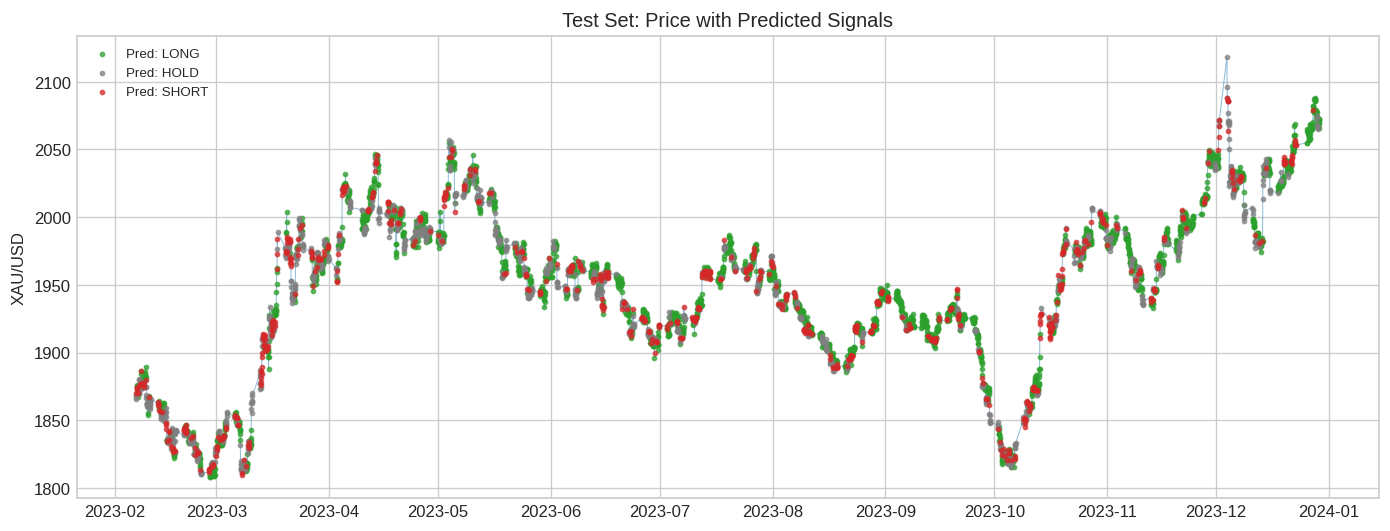

In [16]:
fig, ax = plt.subplots(figsize=(14, 5))

ax.plot(test_pdf.index, test_pdf["close"], color="#1f77b4", linewidth=0.6, alpha=0.5)

pred_series = pd.Series(predictions, index=test_pdf.index)
for label_val, color in PALETTE.items():
    mask = pred_series == label_val
    ax.scatter(
        test_pdf.index[mask], test_pdf.loc[mask, "close"],
        c=color, s=6, alpha=0.7, label=f"Pred: {LABEL_NAMES[label_val]}", zorder=3
    )

ax.set_title("Test Set: Price with Predicted Signals")
ax.set_ylabel("XAU/USD")
ax.legend(fontsize=8)

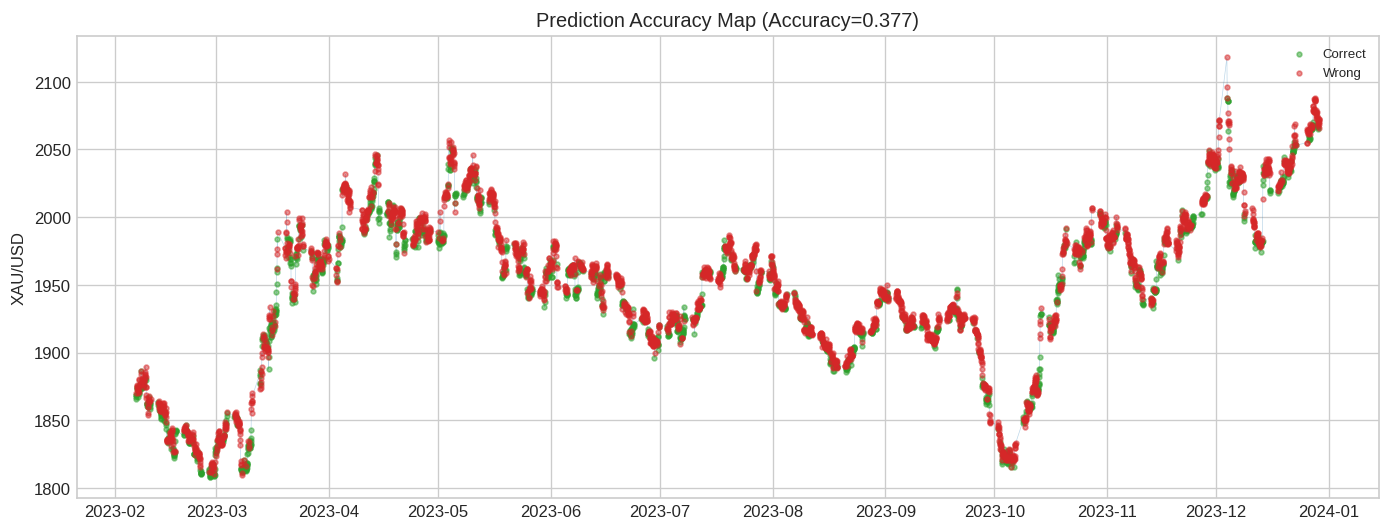

In [17]:
fig, ax = plt.subplots(figsize=(14, 5))

correct = y_true == predictions
ax.scatter(test_pdf.index[correct], test_pdf["close"].iloc[correct], c="#2ca02c", s=8, alpha=0.5, label="Correct", zorder=3)
ax.scatter(test_pdf.index[~correct], test_pdf["close"].iloc[~correct], c="#d62728", s=8, alpha=0.5, label="Wrong", zorder=3)
ax.plot(test_pdf.index, test_pdf["close"], color="#1f77b4", linewidth=0.4, alpha=0.3)

ax.set_title(f"Prediction Accuracy Map (Accuracy={accuracy_score(y_true, predictions):.3f})")
ax.set_ylabel("XAU/USD")
ax.legend(fontsize=8)

Text(0.5, 1.02, 'Predicted Class Probabilities Over Test Period')

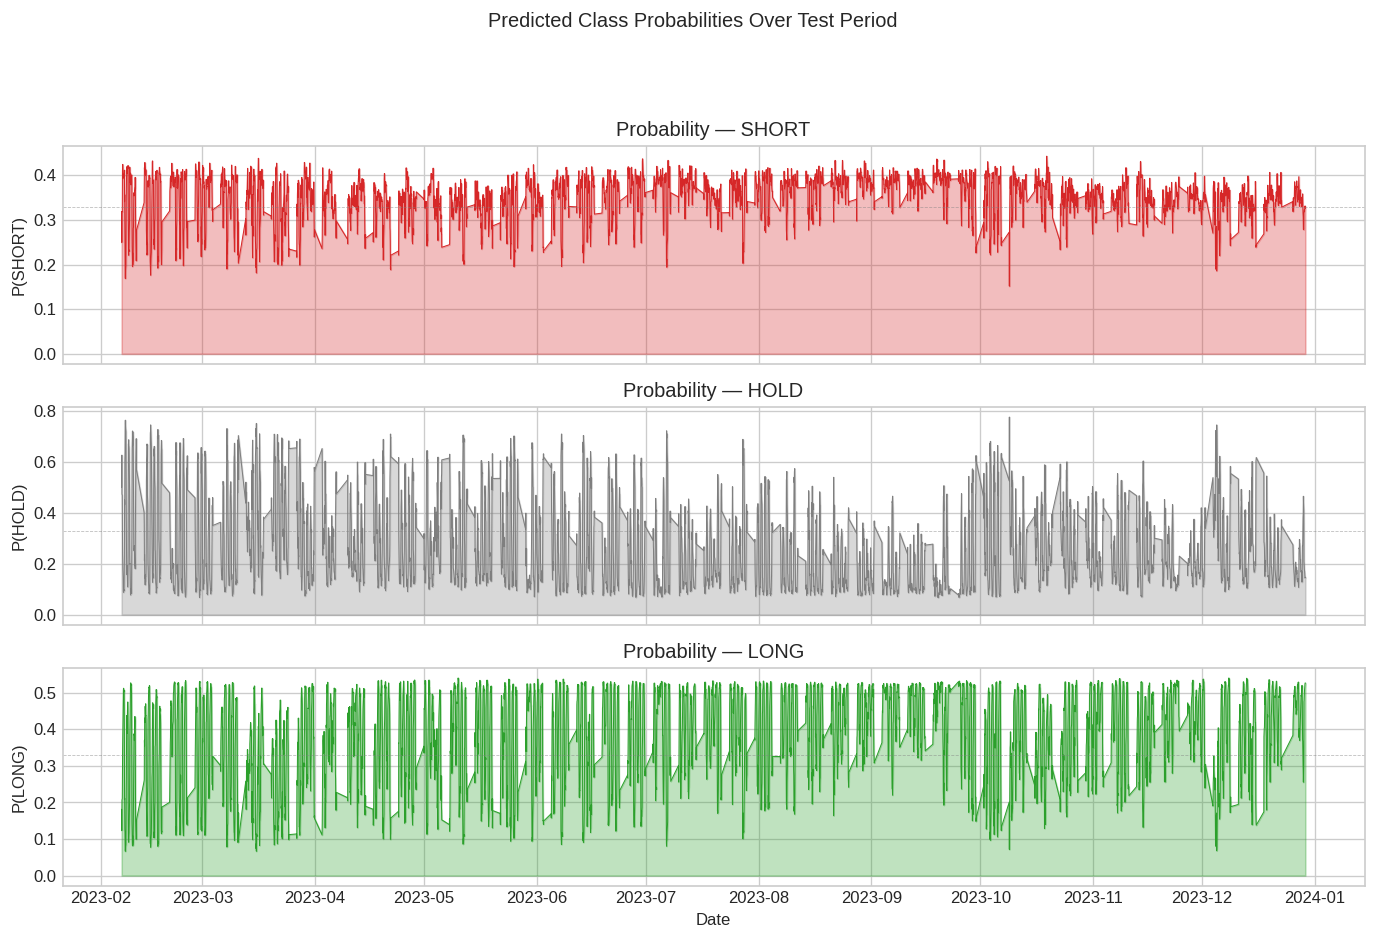

In [18]:
fig, axes = plt.subplots(3, 1, figsize=(14, 8), sharex=True)

proba_labels = model.label_encoder.inverse_transform(model.meta_model.classes_)
proba_by_label = {label: pred_proba[:, i] for i, label in enumerate(proba_labels)}

for label_val, ax in zip(LABELS, axes):
    values = proba_by_label.get(label_val, np.zeros(len(test_pdf)))
    ax.plot(test_pdf.index, values, color=PALETTE[label_val], linewidth=0.6)
    ax.fill_between(test_pdf.index, 0, values, alpha=0.3, color=PALETTE[label_val])
    ax.axhline(0.33, color="gray", linewidth=0.5, linestyle="--", alpha=0.5)
    ax.set_ylabel(f"P({LABEL_NAMES[label_val]})")
    ax.legend(fontsize=8, loc="upper right")
    ax.set_title(f"Probability — {LABEL_NAMES[label_val]}")

axes[-1].set_xlabel("Date")
fig.suptitle("Predicted Class Probabilities Over Test Period", fontsize=12, y=1.02)

## 11. Backtest Visualization

In [19]:
_t_section = time.perf_counter()
metrics = backtest_signals(test, positions, initial_balance=INITIAL_BALANCE)
equity_arr = simulate_equity(test_pdf["close"].to_numpy(), positions, spread=test["spread"].to_numpy(), initial_balance=INITIAL_BALANCE)
equity = pd.Series(equity_arr, index=test_pdf.index, name="equity")
pnl_usd = np.diff(equity_arr, prepend=equity_arr[0])
account_returns = np.diff(equity_arr) / equity_arr[:-1]
account_returns = np.nan_to_num(account_returns, nan=0.0, posinf=0.0, neginf=0.0)
account_returns = np.concatenate([[0.0], account_returns])

bh_equity = (INITIAL_BALANCE * test_pdf["close"] / test_pdf["close"].iloc[0]).rename("bh_equity")
_timings["backtesting"] = time.perf_counter() - _t_section

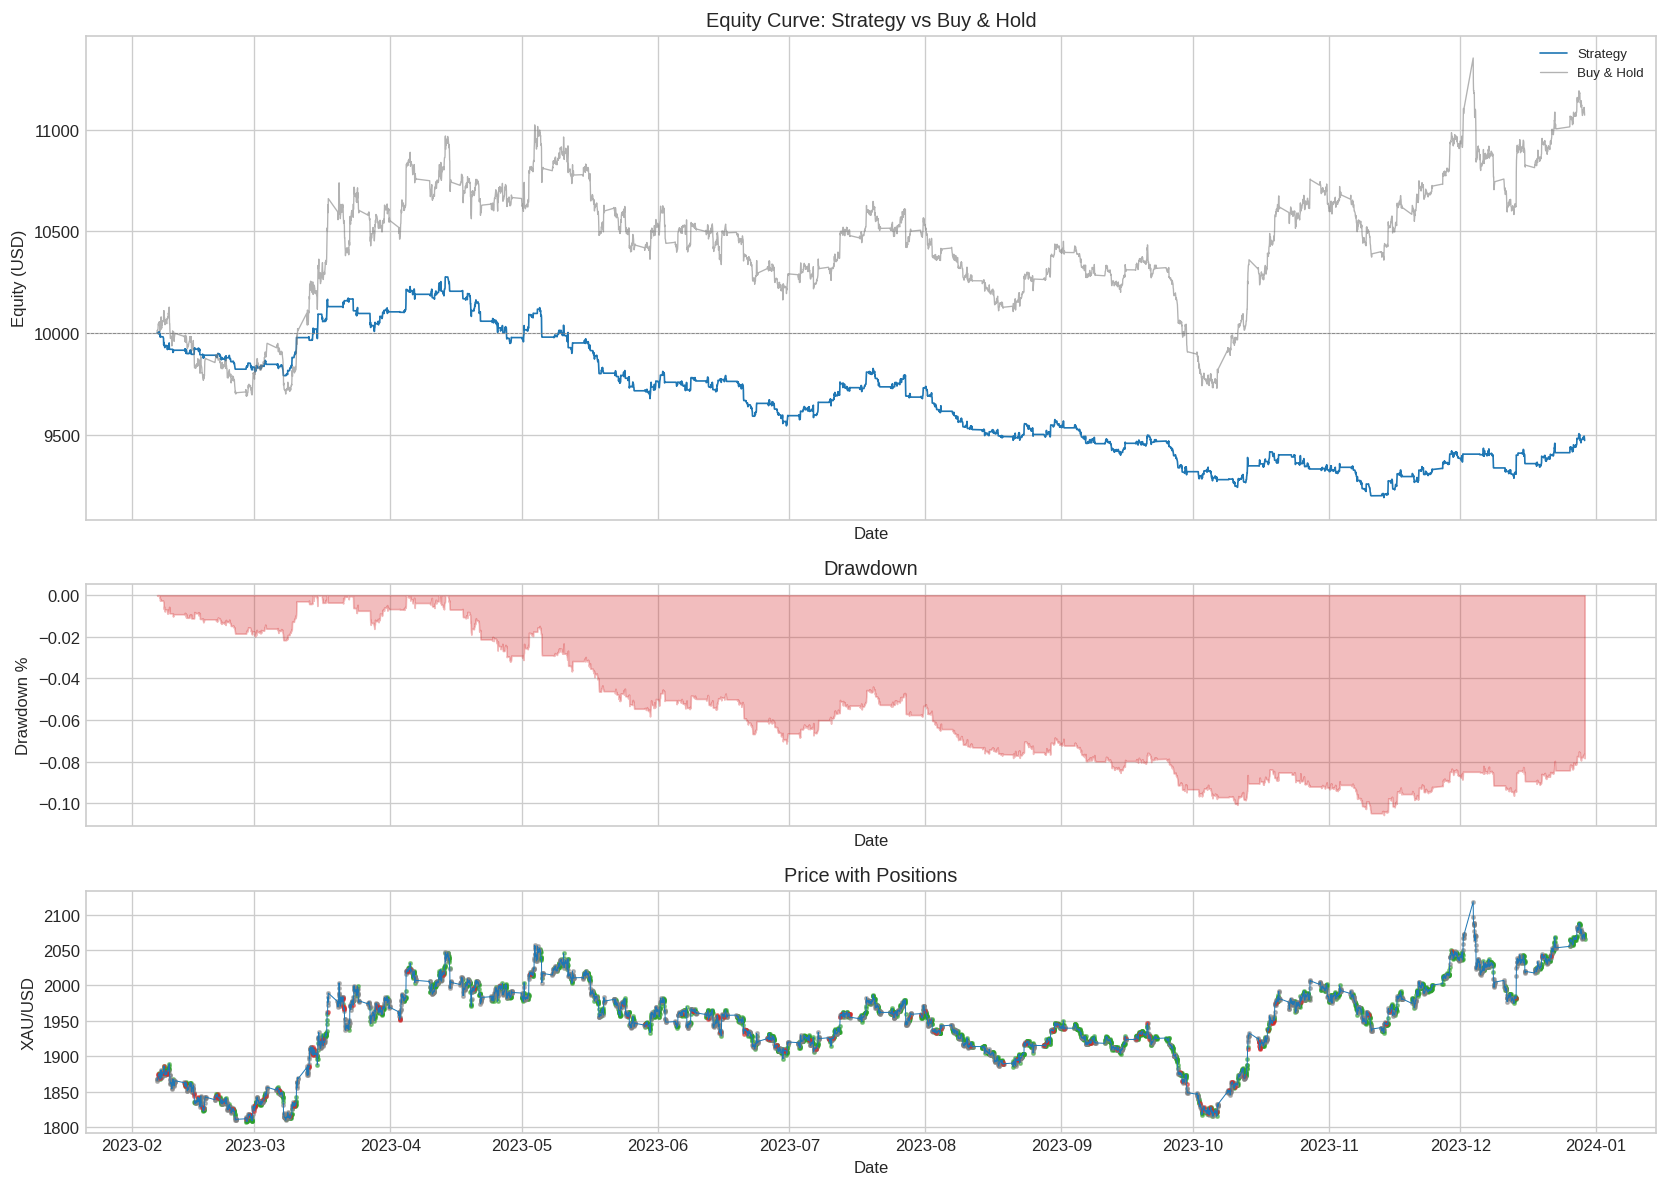

In [20]:
fig, axes = plt.subplots(3, 1, figsize=(14, 10), sharex=True, height_ratios=[2, 1, 1])

axes[0].plot(equity.index, equity.values, color="#1f77b4", linewidth=1, label="Strategy")
axes[0].plot(bh_equity.index, bh_equity.values, color="#7f7f7f", linewidth=0.8, alpha=0.6, label="Buy & Hold")
axes[0].axhline(INITIAL_BALANCE, color="gray", linewidth=0.5, linestyle="--")
axes[0].set_title("Equity Curve: Strategy vs Buy & Hold")
axes[0].set_ylabel("Equity (USD)")
axes[0].legend(fontsize=8)

drawdown = (equity - equity.cummax()) / equity.cummax()
axes[1].fill_between(equity.index, drawdown.values, 0, alpha=0.3, color="#d62728")
axes[1].set_title("Drawdown")
axes[1].set_ylabel("Drawdown %")

axes[2].plot(test_pdf.index, test_pdf["close"], color="#1f77b4", linewidth=0.6)
positions_series = pd.Series(positions, index=test_pdf.index)
for label_val, color in PALETTE.items():
    mask = positions_series == label_val
    axes[2].scatter(test_pdf.index[mask], test_pdf.loc[mask, "close"], c=color, s=4, alpha=0.5)
axes[2].set_title("Price with Positions")
axes[2].set_ylabel("XAU/USD")

for ax in axes:
    ax.set_xlabel("Date")

fig.tight_layout()

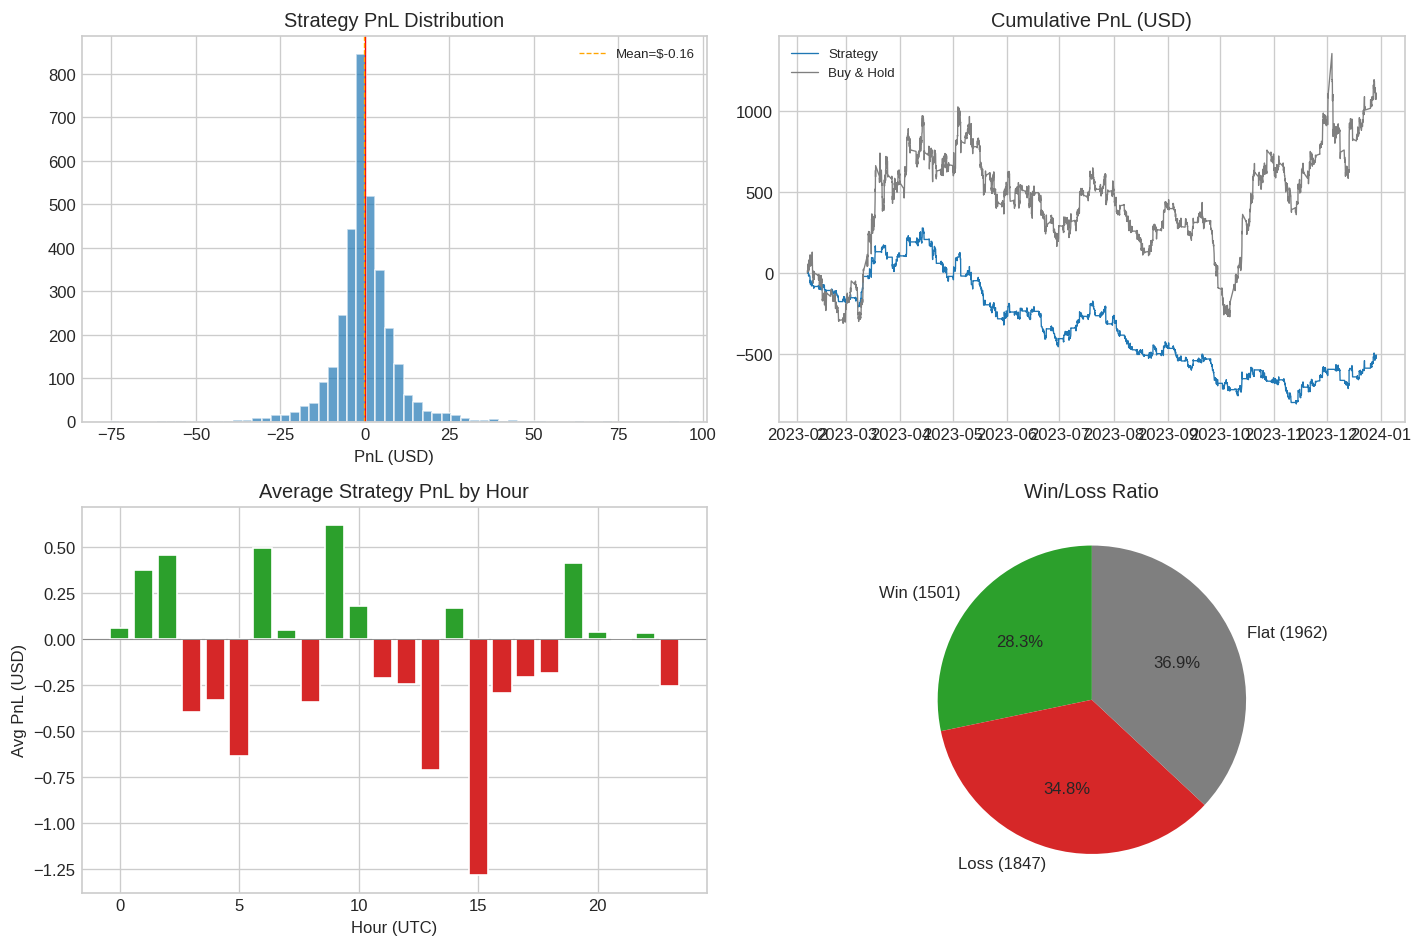

In [21]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8))

nonzero_pnl = pnl_usd[pnl_usd != 0]
mean_pnl = np.mean(nonzero_pnl) if len(nonzero_pnl) else 0.0
axes[0, 0].hist(nonzero_pnl, bins=60, color="#1f77b4", alpha=0.7, edgecolor="white")
axes[0, 0].axvline(0, color="red", linewidth=0.8)
axes[0, 0].axvline(mean_pnl, color="orange", linewidth=0.8, linestyle="--", label=f"Mean=${mean_pnl:.2f}")
axes[0, 0].set_title("Strategy PnL Distribution")
axes[0, 0].set_xlabel("PnL (USD)")
axes[0, 0].legend(fontsize=8)

axes[0, 1].plot(test_pdf.index, equity - INITIAL_BALANCE, color="#1f77b4", linewidth=0.8, label="Strategy")
axes[0, 1].plot(test_pdf.index, bh_equity - INITIAL_BALANCE, color="#7f7f7f", linewidth=0.8, label="Buy & Hold")
axes[0, 1].set_title("Cumulative PnL (USD)")
axes[0, 1].legend(fontsize=8)

hourly = pd.DataFrame({"hour": test_pdf.index.hour, "pnl_usd": pnl_usd})
hourly_grouped = hourly.groupby("hour")["pnl_usd"].mean()
bar_colors = ["#2ca02c" if v > 0 else "#d62728" for v in hourly_grouped.values]
axes[1, 0].bar(hourly_grouped.index, hourly_grouped.values, color=bar_colors, edgecolor="white")
axes[1, 0].axhline(0, color="gray", linewidth=0.5)
axes[1, 0].set_title("Average Strategy PnL by Hour")
axes[1, 0].set_xlabel("Hour (UTC)")
axes[1, 0].set_ylabel("Avg PnL (USD)")

wins = (pnl_usd > 0).sum()
losses = (pnl_usd < 0).sum()
neutral = (pnl_usd == 0).sum()
axes[1, 1].pie(
    [wins, losses, neutral],
    labels=[f"Win ({wins})", f"Loss ({losses})", f"Flat ({neutral})"],
    colors=["#2ca02c", "#d62728", "#7f7f7f"],
    autopct="%.1f%%", startangle=90
)
axes[1, 1].set_title("Win/Loss Ratio")

fig.tight_layout()
plt.show()

Text(0.5, 0, 'Date')

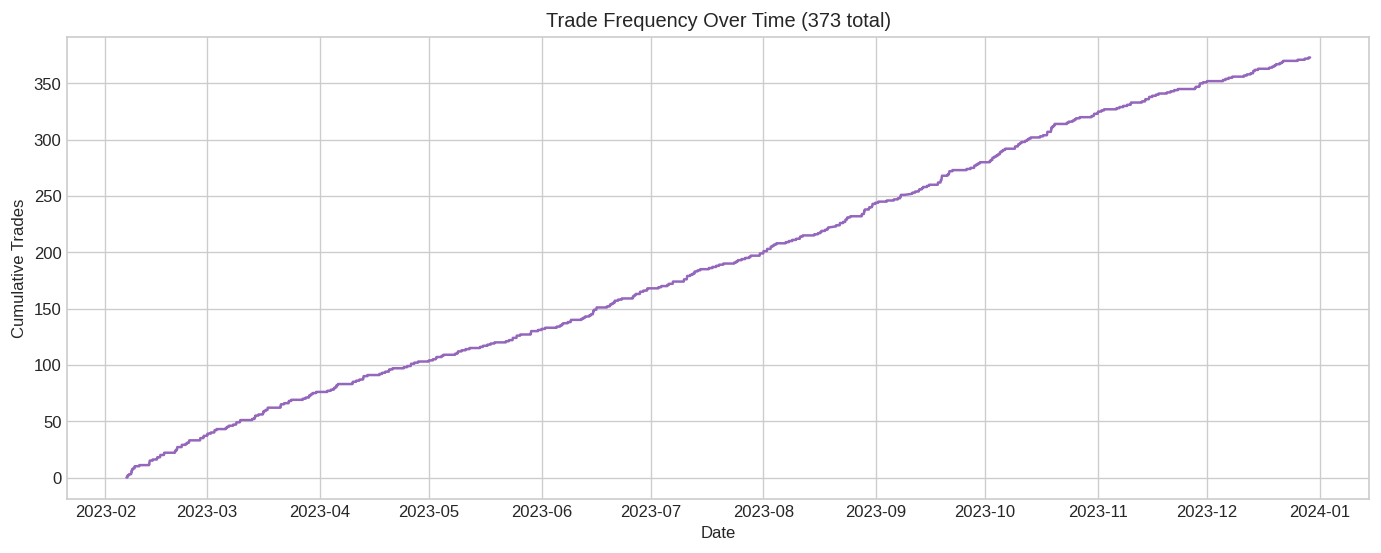

In [22]:
fig, ax = plt.subplots(figsize=(14, 5))

signal_changes = np.diff(positions, prepend=0) != 0
trade_entry_idx = np.where((positions != 0) & signal_changes)[0]

if len(trade_entry_idx) > 0:
    rolling_trades = pd.Series(0, index=test_pdf.index)
    rolling_trades.iloc[trade_entry_idx] = 1
    ax.plot(test_pdf.index, rolling_trades.cumsum(), color="#9467bd", linewidth=1.5)
    ax.set_ylabel("Cumulative Trades")
    ax.set_title(f"Trade Frequency Over Time ({len(trade_entry_idx)} total)")
else:
    ax.set_title("No trades")
    ax.set_ylabel("Trades")

ax.set_xlabel("Date")

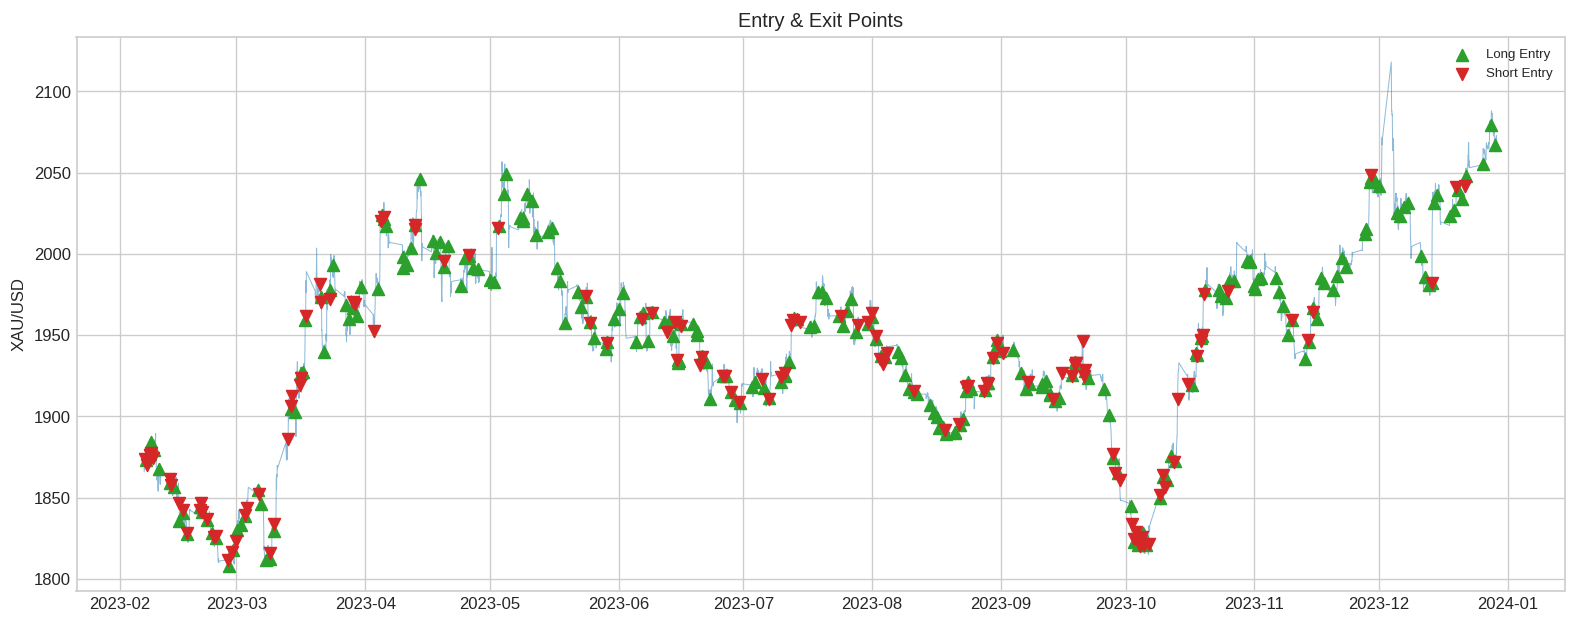

In [23]:
fig, ax = plt.subplots(figsize=(16, 6))

ax.plot(test_pdf.index, test_pdf["close"], color="#1f77b4", linewidth=0.6, alpha=0.5)

long_entries = (positions == 1) & np.r_[True, positions[:-1] != 1]
short_entries = (positions == -1) & np.r_[True, positions[:-1] != -1]

ax.scatter(test_pdf.index[long_entries], test_pdf.loc[long_entries, "close"],
            marker="^", c="#2ca02c", s=50, zorder=5, label="Long Entry")
ax.scatter(test_pdf.index[short_entries], test_pdf.loc[short_entries, "close"],
            marker="v", c="#d62728", s=50, zorder=5, label="Short Entry")

ax.set_title("Entry & Exit Points")
ax.set_ylabel("XAU/USD")
ax.legend(fontsize=8)

## 12. Rolling Performance Metrics

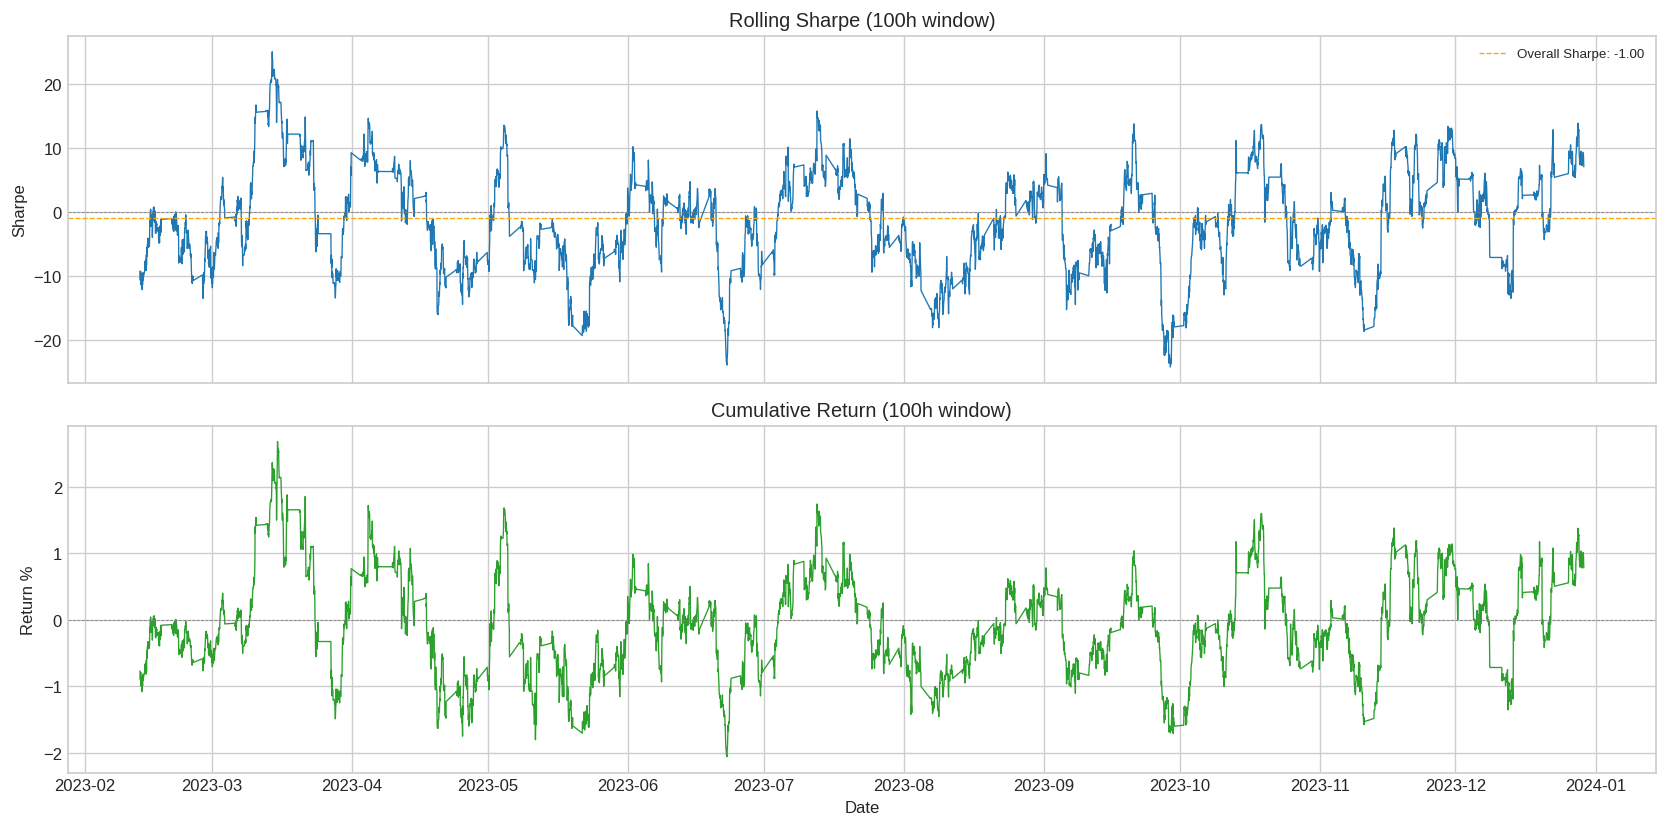

In [24]:
window = max(1, min(100, len(account_returns) // 3))

fig, axes = plt.subplots(2, 1, figsize=(14, 7), sharex=True)

rolling_sharpe = pd.Series(account_returns).rolling(window).apply(
    lambda x: np.sqrt(24 * 252) * x.mean() / x.std() if x.std() > 0 else 0, raw=True
)
axes[0].plot(test_pdf.index, rolling_sharpe.values, color="#1f77b4", linewidth=0.8)
axes[0].axhline(0, color="gray", linewidth=0.5, linestyle="--")
axes[0].axhline(metrics["sharpe"], color="orange", linewidth=0.8, linestyle="--", label=f"Overall Sharpe: {metrics['sharpe']:.2f}")
axes[0].set_title(f"Rolling Sharpe ({window}h window)")
axes[0].set_ylabel("Sharpe")
axes[0].legend(fontsize=8)

rolling_ret = pd.Series(account_returns).rolling(window).sum() * 100
axes[1].plot(test_pdf.index, rolling_ret.values, color="#2ca02c", linewidth=0.8)
axes[1].axhline(0, color="gray", linewidth=0.5, linestyle="--")
axes[1].set_title(f"Cumulative Return ({window}h window)")
axes[1].set_ylabel("Return %")
axes[1].set_xlabel("Date")

fig.tight_layout()

## 13. Summary Dashboard

KeyError: 'trades'

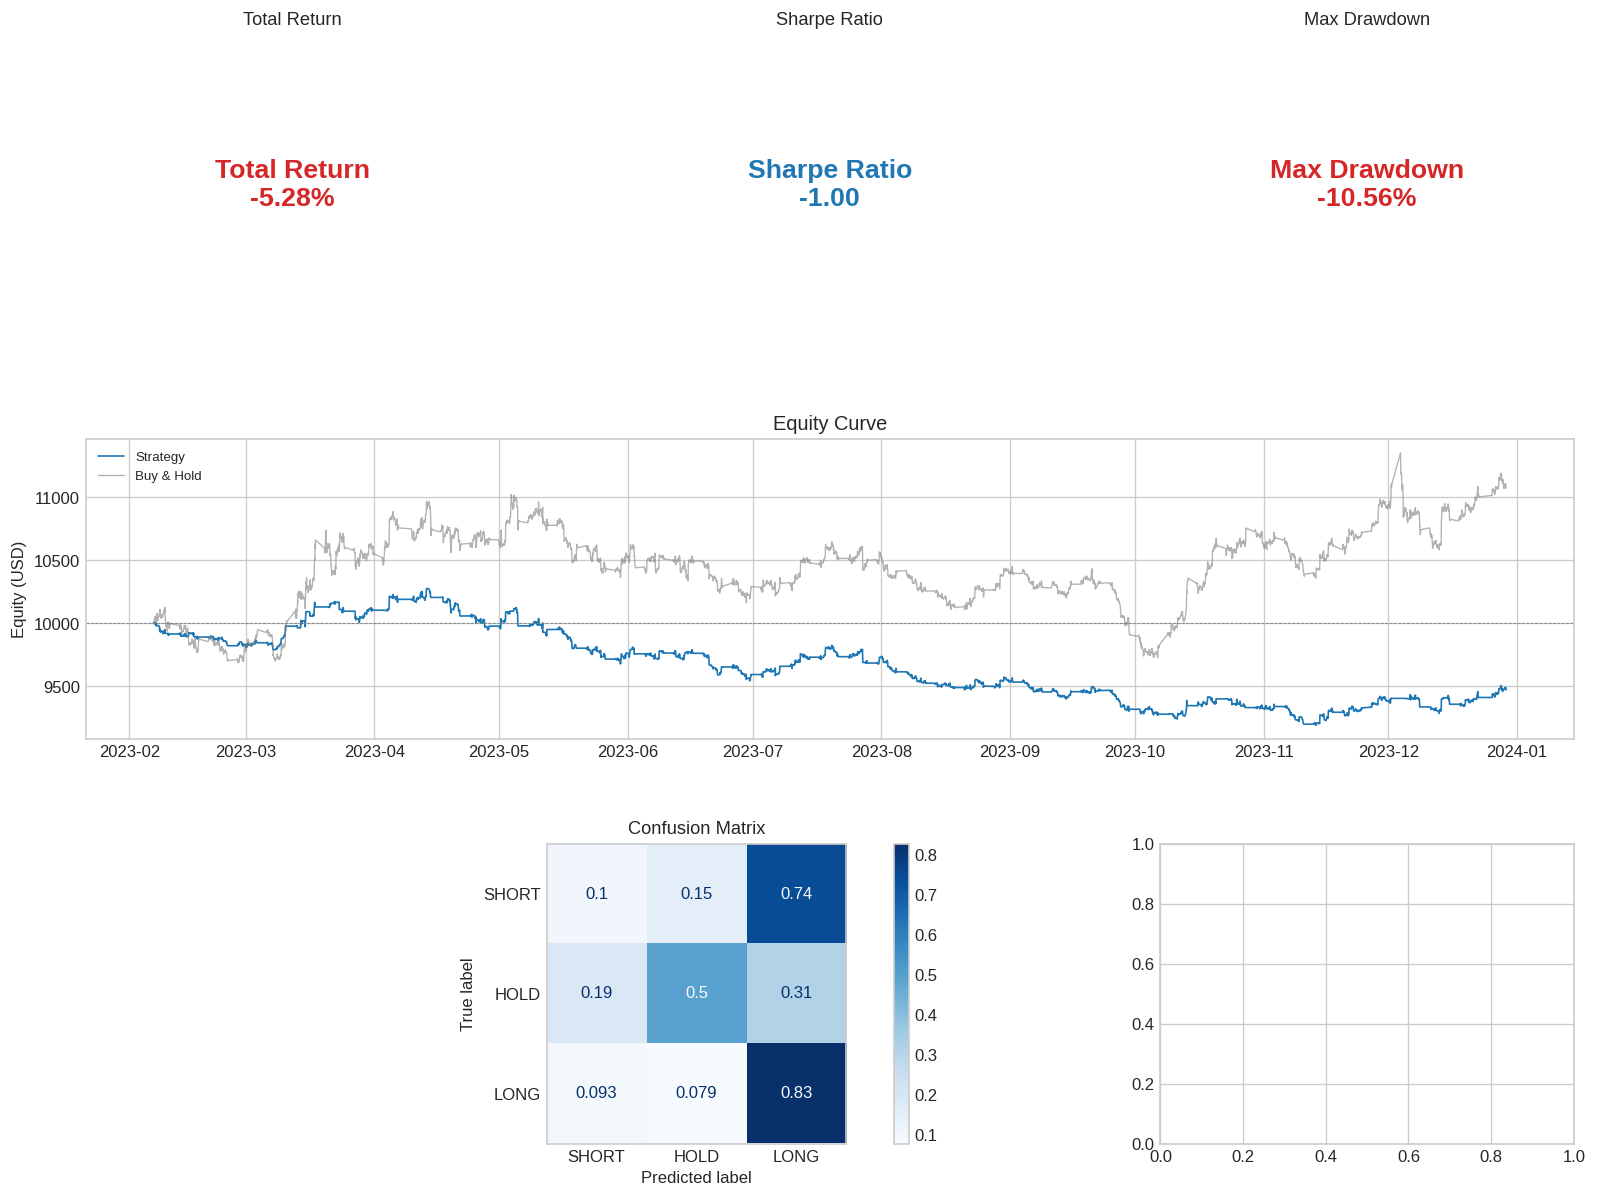

In [25]:
fig = plt.figure(figsize=(16, 12))
gs = gridspec.GridSpec(3, 3, figure=fig, hspace=0.35, wspace=0.3)

ax1 = fig.add_subplot(gs[0, 0])
ax1.text(0.5, 0.5, f"Total Return\n{metrics['total_return']:.2%}",
         ha="center", va="center", fontsize=16, fontweight="bold",
         color="#2ca02c" if metrics["total_return"] > 0 else "#d62728",
         transform=ax1.transAxes)
ax1.set_title("Total Return", fontsize=11)
ax1.axis("off")

ax2 = fig.add_subplot(gs[0, 1])
ax2.text(0.5, 0.5, f"Sharpe Ratio\n{metrics['sharpe']:.2f}",
         ha="center", va="center", fontsize=16, fontweight="bold",
         color="#1f77b4", transform=ax2.transAxes)
ax2.set_title("Sharpe Ratio", fontsize=11)
ax2.axis("off")

ax3 = fig.add_subplot(gs[0, 2])
ax3.text(0.5, 0.5, f"Max Drawdown\n{metrics['max_drawdown']:.2%}",
         ha="center", va="center", fontsize=16, fontweight="bold",
         color="#d62728", transform=ax3.transAxes)
ax3.set_title("Max Drawdown", fontsize=11)
ax3.axis("off")

ax4 = fig.add_subplot(gs[1, :])
ax4.plot(equity.index, equity.values, color="#1f77b4", linewidth=1, label="Strategy")
ax4.plot(bh_equity.index, bh_equity.values, color="#7f7f7f", linewidth=0.8, alpha=0.6, label="Buy & Hold")
ax4.axhline(INITIAL_BALANCE, color="gray", linewidth=0.5, linestyle="--")
ax4.set_title("Equity Curve")
ax4.legend(fontsize=8)
ax4.set_ylabel("Equity (USD)")

ax5 = fig.add_subplot(gs[2, :2])
ConfusionMatrixDisplay.from_predictions(
    y_true, predictions,
    labels=LABEL_ORDER,
    display_labels=[LABEL_NAMES[k] for k in LABEL_ORDER],
    cmap="Blues", ax=ax5, normalize="true",
)
ax5.set_title("Confusion Matrix", fontsize=11)
ax5.grid(False)

ax6 = fig.add_subplot(gs[2, 2])
ax6.text(0.1, 0.9, f"Trades: {int(metrics['trades'])}", transform=ax6.transAxes, fontsize=11)
ax6.text(0.1, 0.75, f"Profit Factor: {metrics['profit_factor']:.2f}", transform=ax6.transAxes, fontsize=11)
ax6.text(0.1, 0.6, f"F1 Macro: {f1_score(y_true, predictions, average='macro', zero_division=0):.4f}", transform=ax6.transAxes, fontsize=11)
ax6.text(0.1, 0.45, f"Accuracy: {accuracy_score(y_true, predictions):.2%}", transform=ax6.transAxes, fontsize=11)
ax6.text(0.1, 0.3, f"Active Models: {len(model.active_model_names_)}", transform=ax6.transAxes, fontsize=11)
ax6.text(0.1, 0.15, f"Features: {len(features)}", transform=ax6.transAxes, fontsize=11)
ax6.text(0.1, 0.0, f"Train/Test: {len(train):,}/{len(test):,}", transform=ax6.transAxes, fontsize=11)
ax6.set_title("Summary Stats", fontsize=11)
ax6.axis("off")

fig.suptitle("Hybrid Stacking XAU/USD — Summary Dashboard", fontsize=14, fontweight="bold", y=1.01)
fig.tight_layout()
plt.show()

## 14. Export

In [ ]:
_t_section = time.perf_counter()
from datetime import datetime
import json

from src.reporting import build_run_data, prediction_results

run_id = f"run_{datetime.now().strftime('%Y%m%d_%H%M%S')}"
run_dir = REPORT_DIR / run_id
run_dir.mkdir(parents=True, exist_ok=True)

results_df = prediction_results(test, predictions, positions, equity_arr)
results_df.to_csv(run_dir / "predictions.csv", index=False)
pd.Series(metrics).to_csv(run_dir / "backtest_metrics.csv")

for fig_num, fig in enumerate(_figures, start=1):
    fig.savefig(run_dir / f"fig_{fig_num:02d}.png", dpi=160, bbox_inches="tight")

artifact_files = sorted(path.name for path in run_dir.iterdir()) + ["run_data.json"]

config_payload = {
    "months": months_label,
    "data_range": file_range,
    "cv_splits": CV_SPLITS,
    "embargo_pct": EMBARGO_PCT,
    "purge_pct": PURGE_PCT,
    "fractional_d": FRACTIONAL_D,
    "min_oof_f1": MIN_OOF_F1,
}

run_data = build_run_data(
    run_dir, model, config_payload, dataset, train, test,
    predictions, positions, results_df, features, metrics, artifact_files,
)
run_data["reproducibility"]["run_entrypoint"] = "notebook"

_timings["reporting"] = time.perf_counter() - _t_section
_timings["total"] = time.perf_counter() - _t0
run_data["timing"] = {k: round(v, 4) for k, v in _timings.items()}

with open(run_dir / "run_data.json", "w", encoding="utf-8") as f:
    json.dump(run_data, f, indent=2, ensure_ascii=False)

print(f"Run saved to: {run_dir}")
print(f"Files: predictions.csv, backtest_metrics.csv, run_data.json, {len(_figures)} figures")

print("\n=== PIPELINE TIMING ===")
for step, elapsed in sorted(_timings.items(), key=lambda x: x[1], reverse=True):
    print(f"  {step}: {elapsed:.4f}s")
print(f"  TOTAL: {_timings['total']:.4f}s")